<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/Hypothesis_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uber shows every rider an **ETA** before they book. Today the operations team wants to know whether riders can trust it

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Viz Helpers

In [ ]:
# === DATA + PICTURE HELPERS — run this cell, then ignore it ========
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def load_uber(seed=11):
    "The same Uber ride file from Sessions 5 and 6 (simulated for teaching)."
    rng = np.random.default_rng(seed)
    slots = 24 * 30
    per_slot = rng.poisson(6, slots)
    hour_slot = np.repeat(np.arange(slots), per_slot)
    n = len(hour_slot)
    hour = hour_slot % 24
    peak = np.isin(hour, [8, 9, 10, 17, 18, 19])
    trip = np.clip(rng.normal(24, 6, n), 4, None).round(1)
    fare = 45 + 11 * trip + rng.normal(0, 25, n)
    surge = rng.random(n) < 0.02
    fare = np.where(surge, fare * rng.uniform(2.0, 2.8, n), fare)
    cancelled = (rng.random(n) < np.where(peak, 0.20, 0.08)).astype(int)
    fraud = (rng.random(n) < 0.01).astype(int)
    flagged = (rng.random(n) < np.where(fraud == 1, 0.90, 0.05)).astype(int)
    data =  pd.DataFrame({
        "hour_slot": hour_slot, "hour": hour, "is_peak": peak.astype(int),
        "trip_minutes": trip, "fare": fare.round(2), "surge": surge.astype(int),
        "cancelled": cancelled, "is_fraud": fraud, "flagged": flagged})
    return add_eta(data)

def add_eta(rides, seed=7):
    "NEW for today: the ETA the app promised the rider before the trip started."
    rng = np.random.default_rng(seed)
    optimism = np.where(rides["is_peak"] == 1, 3.0, 0.8)
    rides["eta_minutes"] = (rides["trip_minutes"] - optimism
                            + rng.normal(0, 2.5, len(rides))).round(1)
    rides["eta_error"] = (rides["trip_minutes"] - rides["eta_minutes"]).round(1)
    return rides

def _axes(title, xlabel, ylabel, size=(6, 4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def show_groups(a, b, name_a, name_b, title, xlabel):
    "Two overlaid histograms with a dashed line at each group's mean."
    ax = _axes(title, xlabel, "how often")
    bins = np.histogram_bin_edges(np.concatenate([a, b]), bins=28)
    for values, name, c in [(a, name_a, COLORS[0]), (b, name_b, COLORS[1])]:
        ax.hist(values, bins=bins, color=c, alpha=0.55, label=name, density=True)
        ax.axvline(np.mean(values), color=c, lw=2, ls="--")
    ax.set_ylabel("share of rides"); ax.legend(frameon=False)
    plt.show()

def show_paired(before, after, title):
    "One line per ride, joining its promised ETA to its actual trip time."
    ax = _axes(title, "promised ETA  ->  actual minutes", "one line per ride", (6, 5))
    order = np.argsort(before)
    for i, j in enumerate(order):
        c = COLORS[1] if after[j] > before[j] else COLORS[2]
        ax.plot([before[j], after[j]], [i, i], color=c, lw=1.3)
        ax.plot(before[j], i, "o", color=c, ms=3, mfc="white")   # promised
        ax.plot(after[j], i, "o", color=c, ms=4)                 # actual
    ax.set_yticks([]); ax.grid(False)
    ax.plot([], [], color=COLORS[1], lw=1.3, label="ran over the ETA")
    ax.plot([], [], color=COLORS[2], lw=1.3, label="beat the ETA")
    ax.legend(frameon=False, loc="lower right")
    plt.show()

def show_scatter(x, y, title, xlabel, ylabel, highlight=None):
    ax = _axes(title, xlabel, ylabel)
    ax.scatter(x, y, s=9, alpha=0.35, color=COLORS[0])
    if highlight is not None:
        ax.scatter(x[highlight], y[highlight], s=22, color=COLORS[1], label="surge ride")
        ax.legend(frameon=False)
    plt.show()

def show_line(x, y, title, xlabel, ylabel):
    ax = _axes(title, xlabel, ylabel)
    ax.plot(x, y, "o-", color=COLORS[0], ms=5, lw=1.5)
    ax.margins(y=0.20); plt.show()

## T-Test

In [ ]:
rides = load_uber()
print("rides loaded:", len(rides))
rides.head()

rides loaded: 4328


,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged,eta_minutes,eta_error
0,0,0,0,30.6,425.04,0,0,0,0,29.8,0.8
1,0,0,0,27.7,326.40,0,0,0,0,27.6,0.1
2,0,0,0,23.8,281.49,0,0,0,0,22.3,1.5
3,1,1,0,16.0,253.05,0,0,0,0,13.0,3.0
4,1,1,0,21.3,305.81,0,0,0,0,19.4,1.9



| | Claim |
|---|---|
| **H₀** | μ ≥ 25 minutes — the published figure stands |
| **H₁** | μ < 25 minutes — trips really are quicker |

In [ ]:
sample = rides['trip_minutes'].sample(200, random_state=42)
t_stat, p_value = stats.ttest_1samp(sample, 25, alternative="less") # H1 : mu < 25

print("sample mean:", round(sample.mean(), 2), "minutes")
print("t =", round(t_stat, 4), " df =", len(sample) - 1)
print("p =", round(p_value, 4))

sample mean: 24.05 minutes
t = -2.2924  df = 199
p = 0.0115


## 2 sampled t-test

| | Claim |
|---|---|
| **H₀** | the ETA is short by the same amount at peak and off-peak (μ_peak = μ_off) |
| **H₁** | the ETA is short by **more** at peak (μ_peak > μ_off) |

In [ ]:
peak_error = rides[rides["is_peak"] == 1]["eta_error"]
off_error  = rides[rides["is_peak"] == 0]["eta_error"]

In [ ]:
print(off_error.mean())
print(peak_error.mean())

0.8357843137254902
3.0625


In [ ]:
off_error.shape

(3264,)

In [ ]:
peak_error.shape

(1064,)

In [ ]:
t_stat, p_value = stats.ttest_ind(peak_error, off_error, equal_var=False, alternative= "greater")

print("rush hour  : ", len(peak_error), "rides, ETA short by", round(peak_error.mean(), 2), "min")
print("off-peak   : ", len(off_error), "rides, ETA short by", round(off_error.mean(), 2), "min")

print("t =", round(t_stat, 2), " p =", p_value)

rush hour  :  1064 rides, ETA short by 3.06 min
off-peak   :  3264 rides, ETA short by 0.84 min
t = 25.37  p = 6.465183880597077e-122


Riders assume rush-hour trips take **longer**, not just that the ETA is worse.
Test it.

1. Split `rides["trip_minutes"]` into peak and off-peak, exactly as above




```
H0 : both peak and non-peak duration are same. mu-peak = mu-non-peak
H1 : mu-peak > mu-non-peak
```





In [ ]:
peak_duration = rides[rides["is_peak"] == 1]["trip_minutes"]
off_duration  = rides[rides["is_peak"] == 0]["trip_minutes"]

In [ ]:
peak_duration.mean(), off_duration.mean()

(np.float64(24.51447368421053), np.float64(23.99234068627451))

In [ ]:
t_stat, p_value = stats.ttest_ind(peak_duration, off_duration, equal_var=False, alternative= "greater")
print("t =", round(t_stat, 2), " p =", p_value)

t = 2.41  p = 0.007941185254069168


In [ ]:
rides.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged,eta_minutes,eta_error
0,0,0,0,30.6,425.04,0,0,0,0,29.8,0.8
1,0,0,0,27.7,326.40,0,0,0,0,27.6,0.1
2,0,0,0,23.8,281.49,0,0,0,0,22.3,1.5
3,1,1,0,16.0,253.05,0,0,0,0,13.0,3.0
4,1,1,0,21.3,305.81,0,0,0,0,19.4,1.9


## Paird t-test

| | Claim |
|---|---|
| **H₀** | the app's ETA is right on average (mean of `actual − promised` = 0) |
| **H₁** | the ride runs **longer** than promised (mean of `actual − promised` > 0) |

In [ ]:
audit = rides.sample(40, random_state=7)
audit.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged,eta_minutes,eta_error
1597,274,10,1,18.7,225.47,0,0,0,0,15.3,3.4
2091,356,20,0,22.0,310.16,0,0,0,0,26.4,-4.4
1042,180,12,0,35.4,365.36,0,0,0,0,39.0,-3.6
498,87,15,0,30.3,371.45,0,0,0,0,32.1,-1.8
3378,571,19,1,24.8,319.01,0,0,0,0,21.2,3.6


In [ ]:
audit['trip_minutes'].mean(), audit['eta_minutes'].mean()

(np.float64(24.5125), np.float64(23.1325))

In [ ]:
t_paired, p_paired = stats.ttest_rel(audit['trip_minutes'], audit['eta_minutes'], alternative="greater")

print("average promised ETA :", round(audit["eta_minutes"].mean(), 2), "min")
print("average actual trip  :", round(audit["trip_minutes"].mean(), 2), "min")
print()
print("PAIRED       t =", round(t_paired, 2), " p =", round(p_paired, 4))

average promised ETA : 23.13 min
average actual trip  : 24.51 min

PAIRED       t = 2.92  p = 0.0029


## Chi-sq test


| | Claim |
|---|---|
| **H₀** | rush hour and cancellation are **independent** — no relationship |
| **H₁** | they are **related** |




In [ ]:
rides.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged,eta_minutes,eta_error
0,0,0,0,30.6,425.04,0,0,0,0,29.8,0.8
1,0,0,0,27.7,326.40,0,0,0,0,27.6,0.1
2,0,0,0,23.8,281.49,0,0,0,0,22.3,1.5
3,1,1,0,16.0,253.05,0,0,0,0,13.0,3.0
4,1,1,0,21.3,305.81,0,0,0,0,19.4,1.9


In [ ]:
table = pd.crosstab(rides["is_peak"], rides["cancelled"])

print(table)
print()
print("off-peak cancellation rate:", round(rides[rides["is_peak"] == 0]["cancelled"].mean(), 3))
print("rush-hour cancellation rate:", round(rides[rides["is_peak"] == 1]["cancelled"].mean(), 3))

cancelled     0    1
is_peak             
0          2984  280
1           875  189

off-peak cancellation rate: 0.086
rush-hour cancellation rate: 0.178


In [ ]:
rides['cancelled'].mean()

np.float64(0.1083641404805915)

In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(table)

In [ ]:
print("expected counts if there were NO relationship:")
print(np.round(expected, 1))
print()
print("chi-square =", round(chi2, 2), " degrees of freedom =", dof)

expected counts if there were NO relationship:
[[2910.3  353.7]
 [ 948.7  115.3]]

chi-square = 69.11  degrees of freedom = 1
p = 9.304534022326267e-17


In [ ]:
rides[rides["is_peak"] == 1].shape[0]*0.108

114.91199999999999

previous Session fraud detector: `is_fraud` is whether a ride really was fraudulent,
`flagged` is whether the detector raised an alarm. If the detector works at all,
those two must be related.

1. Build a contingency table of `is_fraud` against `flagged` with `pd.crosstab`
2. Run `stats.chi2_contingency` and print the chi-square statistic and p-value


In [ ]:
rides.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged,eta_minutes,eta_error
0,0,0,0,30.6,425.04,0,0,0,0,29.8,0.8
1,0,0,0,27.7,326.40,0,0,0,0,27.6,0.1
2,0,0,0,23.8,281.49,0,0,0,0,22.3,1.5
3,1,1,0,16.0,253.05,0,0,0,0,13.0,3.0
4,1,1,0,21.3,305.81,0,0,0,0,19.4,1.9


## Correlation test

H0 : both the feature are independent no corrleation.

H1 : correlation exits.

In [ ]:
r, p_value = stats.pearsonr(rides["trip_minutes"], rides["fare"])

print("r =", round(r, 3))
print("p =", p_value)

r = 0.728
p = 0.0


In [ ]:
X = np.random.randn(200,2)
X[:5]

array([[-0.87893409,  0.68501722],
       [-1.7230601 ,  0.09326068],
       [-1.1263145 ,  0.52994606],
       [-0.04469929, -0.61589099],
       [ 0.33602661, -0.71900935]])

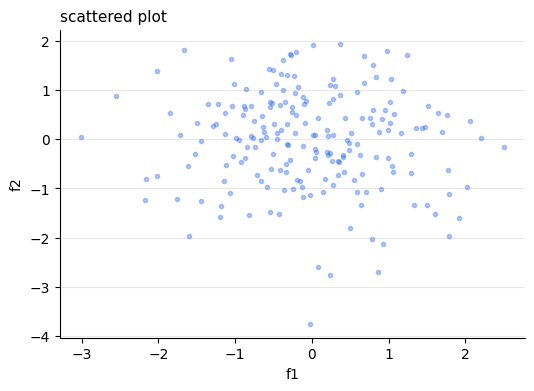

In [ ]:
show_scatter(X[:,0], X[:, 1],
             "scattered plot","f1", "f2")

In [ ]:
r, p_value = stats.pearsonr(X[:,0], X[:, 1])

print("r =", round(r, 3))
print("p =", p_value)

r = -0.072
p = 0.31312032305609266


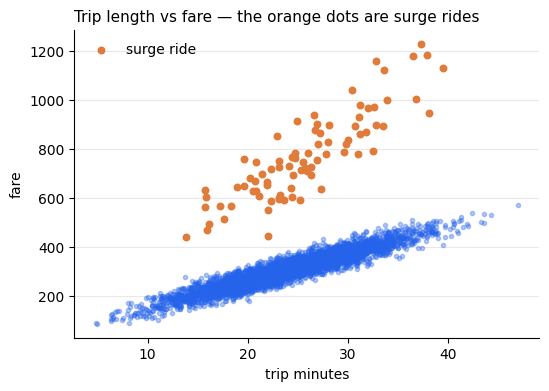

In [ ]:
show_scatter(rides["trip_minutes"], rides["fare"],
             "Trip length vs fare — the orange dots are surge rides",
             "trip minutes", "fare",
             highlight=(rides["surge"] == 1).values)

In [ ]:
normal_rides = rides[rides["surge"] == 0]

r_no_surge, _ = stats.pearsonr(normal_rides["trip_minutes"], normal_rides["fare"])

print("the 4,246 normal rides: r =", round(r_no_surge, 3))

the 4,246 normal rides: r = 0.938


In [ ]:
# correlation doesnt imply causation.